In [115]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict,Literal

In [116]:
code_reviewer = ChatOllama(model="llama3.2:1b")
code_imporover=ChatOllama(model="llama3.2:1b")

In [117]:
class CodeReview(TypedDict):
    code: str
    review: Literal["yes","no"]
    improve: str
    score: int
    

In [153]:
def check_error(state:CodeReview):
    code = state["code"]
    improve_code=state["improve"]
    prompt=""
    if improve_code!="":
        prompt=f"""
You are a senior developer.

Check this code:
{improve_code}

Rules:
- If code has any error return only: yes
- If code has no error return only: no

Return ONLY yes or no.
"""
    else:
        prompt=prompt=f"""
You are a senior developer.

Check this code:
{code}

Rules:
- If code has any error return only: yes
- If code has no error return only: no

Return ONLY yes or no.
"""


    review = code_reviewer.invoke(prompt).content.strip().lower()

    if "yes" in review:
        review="yes"
    else:
        review="no"

    return {
        "code": code,
        "review": review,
        "improve": state["improve"],
        "score": state["score"]
    }

In [175]:
def code_improver(state:CodeReview)->CodeReview:
    code=state["code"]
    if state["score"]<=5:
        if state["improve"]!="":
            code=state["improve"]
        prompt=f"you are senior degubber remove all error form this {code} ans return the clean code only "
        imporve=code_imporover.invoke(prompt).content

    else:
        return "Agent are in the loop"
    
    state["score"]+=1

    return {"review":state["review"],"improve":imporve,"score":state["score"]}
    



In [176]:
def check_condition(state:CodeReview)->CodeReview:
    return state["review"]
    


In [177]:
def noerror(state:CodeReview)->CodeReview:
    return {"improve":"their are no error in the code"}

In [178]:
graph=StateGraph(
    CodeReview
)

In [179]:
graph.add_node("check_error",check_error)
graph.add_node("code_imporover",code_improver)
graph.add_node("no_error",noerror)

In [180]:
graph.add_edge(START,"check_error")
graph.add_conditional_edges("check_error",check_condition,{"yes":"code_imporover","no":END})

graph.add_edge("code_imporover","check_error")


app=graph.compile()

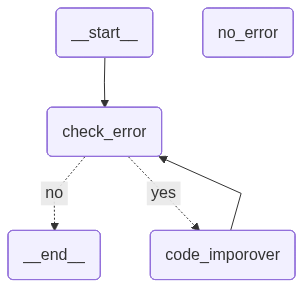

In [181]:
app

In [182]:
result=app.invoke({"code":"pt(3+2)","score":0,"improve":"","review":""})
print(result)

{'code': 'pt(3+2)', 'review': 'no', 'improve': "Here's the corrected and cleaned code:\n\n```python\ndef calculate_result():\n    return (3 + 2)\n\nresult = calculate_result()\nprint(result)\n```\n\nExplanation of corrections:\n\n- Renamed function to `calculate_result` to make it more descriptive.\n- Removed unnecessary comments as they are not required for understanding the code.\n- Removed duplicate variable name `3+2` since we're using a single variable and function name.", 'score': 1}
